In [1]:
train_dir = "Fruits/train/train"
test_dir ="Fruits/test"

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
#Führt das Modell auf der GPU aus, sonst auf der CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

#Fixiert den random seed damit Ergebnisse reproduziert werden können
torch.manual_seed(42)

Device: cuda


In [4]:
#Definition der Hyperparameter für das Modell
IMG_HEIGHT = 100
IMG_WIDTH = 100
CHANNELS = 3    #Drei channel weil RGB
BATCH_SIZE = 32   #Wie viele Trainingsbeispiele gleichzeitig verarbeitet werden
NUM_CLASSES = 33    #Anzahl der verschiedenen Fruchtsorten
EPOCHS = 2

In [5]:
#Datenvorverarbeitungs- und Augmentationsblock
train_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomRotation(20),    #Dreht das Bild zufällig um +/-20°
    transforms.RandomHorizontalFlip(),    #Spiegelt das Bild zufällig horizontal
    transforms.RandomAffine(    #Zufällige Verschiebung in x- und y-Richtung, Zoom in oder out, Rotation bereits oben festgelegt
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    #Wandelt Bilder in einen Tensor (mehrdimensionale Matrix) um und normalisiert diese auf -1 bis 1 für Stabileres Training
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

#Keine Augmentation für Testbilder
test_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])


In [6]:
# 1. Define the split sizes first
total_len = len(datasets.ImageFolder(root=train_dir))
train_size = int(0.8 * total_len)
val_size = total_len - train_size

# 2. Generate consistent indices for the split
# Fix the generator seed so the split is always the same
generator = torch.Generator().manual_seed(123)
train_dataset, val_dataset = random_split(range(total_len), [train_size, val_size], generator=generator)

# Get the indices from the random split
train_indices = train_dataset.indices
val_indices = val_dataset.indices

# 3. Create two separate datasets
# One with augmentation
train_data_source = datasets.ImageFolder(root=train_dir, transform=train_transform)
# One without augmentation (clean)
val_data_source = datasets.ImageFolder(root=train_dir, transform=test_transform)

# 4. Create the final Subsets using the indices
train_dataset = Subset(train_data_source, train_indices)
val_dataset = Subset(val_data_source, val_indices)

# Now train_dataset uses train_transform, and val_dataset uses test_transform

In [7]:
#Bereitstellung der Daten für das Modell, nimmt hyperparameter batch size, bei Training shuffeln wir die Bilder damit keine Reihenfolgemuster gelernt werden
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 13483
Validation samples: 3371


##Feature Extraction:
**Conv2d:**

*   in_channels=3 -> RGB Bild
*   out_channels=32 -> 32 Filter die unterschiedliche Muster erkennen (z. B. Kanten, Farben, Texturen)
*   kernel_size=3 -> Größe der Filter = 3×3 Pixel

Erstellung von Feature Maps
<br>
<br>
**ReLU:**<br>
Aktivierungsfunktion -> fügt Nichtlinearität hinzu, ohne ReLU könnte das CNN nur lineare Muster lernen
<br>
<br>
**MaxPool2d:**<br>
Reduziert räumliche Größe der Feature-Maps um Faktor 2, weniger Paramter und robust gegen kleine Verschiebungen im Bild
<br>
<br>
<br>
Anschließend 64 Filter und dann 128 Filter mit gleicher Logik (channel in immer der Wert des channel out vom vorherigen Block)<br>
Mit jedem Block werden komplexere und abstraktere Merkmale erlernt
<br>
<br>
## Classification head

**Flatten:**

Wandelt die 3D-Feature-Maps in einen Vektor um -> nötig für Dense Layer
(Convolutional Layer arbeitet räumlich (2D), Dense Layer nicht)
<br>
<br>
**Linear:**<br>
Kombiniert alle gelernten Merkmale, lernt welche Feature-Kombinationen typisch für welche Klasse sind (Input: 18.432 gelernte Features, Output: 256 Neuronen)
<br>
-> ein Dense Layer (Fully Connected Layer), jedes der 256 Neuronen (ein Neuron lernt eine bestimmte Kombination von Merkmalen, z.B. langgestreckt + gelb + gebogen) ist mit allen Eingabewerten verbunden (alle gelernten Features)
<br>
<br>
**ReLU:**<br>
Dense Layer arbeitet anders als Convolutional Layer (global, keine räumliche Struktur, Gewichtsmatrix (wie wichtig ist ein Feature für ein Neuron))
<br>
<br>
**Dropout:**<br>
während Training werden 50 % der Neuronen zufällig deaktiviert (es kann sich nicht auf einzelne Neuronen verlassen)
<br>
<br>
**Linear:**<br>
Finale output Layer, 256 Features (ein Feature pro Neuron) werden in 33 Werte umgewandelt, wobei jeder Wert einer Fruchtklasse entspricht

In [8]:
model = nn.Sequential(
    # ----- Feature extraction -----
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),  # 100x100 -> 50x50

    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),  # 50x50 -> 25x25

    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),  # 25x25 -> 12x12

    # ----- Classification head -----
    nn.Flatten(),
    nn.Linear(128 * 12 * 12, 256),  # 128 channels, each 12x12 pixels
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
).to(device)

print(model)


Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=18432, out_features=256, bias=True)
  (11): ReLU()
  (12): Dropout(p=0.5, inplace=False)
  (13): Linear(in_features=256, out_features=33, bias=True)
)


**Loss-Funktion**

Was es macht:
Vergleicht die vom Modell vorhergesagten Logits (Ausgabewerte des letzten Layers, noch keine Wahrscheinlichkeiten) mit den echten Labels.
→ Berechnet, wie „falsch“ das Modell liegt.

Warum CrossEntropyLoss:

Für Multi-Klassen-Klassifikation geeignet (hier: 33 Fruchtklassen).

Intern wendet CrossEntropy Softmax auf die Logits an, um Wahrscheinlichkeiten zu erzeugen.

Misst, wie gut die Wahrscheinlichkeitsverteilung der Vorhersage zu den tatsächlichen Labels passt.

Merksatz:
„Loss sagt dem Modell, wie sehr es daneben liegt, damit die Gewichte beim Backpropagation angepasst werden können.“
<br>
<br>
**Optimizer**

Was es macht:
Aktualisiert die Gewichte des Modells, um den Loss zu minimieren.
→ Führt das „Lernen“ durch Gradientenschritte aus.

Warum Adam:

Beliebter Optimizer für CNNs.

Kombiniert Momentum + adaptive Lernraten pro Parameter.

Meist schneller und stabiler als normales SGD.

Parameter:

model.parameters() → Alle Gewichte im Modell werden trainiert.

lr=1e-3 → Lernrate: Schrittgröße bei jedem Update.

Merksatz:
„Der Optimizer entscheidet, wie die Gewichte angepasst werden, um den Loss zu minimieren.“

In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [10]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(1, EPOCHS + 1):
    #Training
    model.train()
    running_train_loss = 0.0
    correct_train, total_train = 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        #Setzt Gradienten aller Parameter auf 0, bevor loss.backward() neue Gradienten berechnet
        optimizer.zero_grad()
        #Berechnet die Vorhersagen für jede Klasse (logits = rohe Ausgabewerte aus Dense Layer, noch keine Wahrscheinlichkeiten)
        logits = model(x)
        #Berechnet den Fehler zwischen den vorhergesagten Logits und den tatsächlichen Labels (einzelner Wert, der angibt, wie „falsch“ das Modell lag)
        loss = loss_fn(logits, y)
        #Backpropagation, berechnet die Gradienten der Gewichte in Bezug auf den Loss
        loss.backward()
        #Gewichte aktualisieren
        optimizer.step()

        #Gesamte Loss Summe in dieser Epoche
        running_train_loss += loss.item()
        #Bestimmt für jedes Bild die Klasse mit dem höchsten Logits Wert -> tatsächliche Vorhersage des Modells
        pred = logits.argmax(dim=1)
        #Zählt wie viele Bilder korrekt klassifiziert wurden
        correct_train += (pred == y).sum().item()
        #Zählt die Gesamtzahl der Bilder
        total_train += y.size(0)

    #Durchschnittlicher Loss dieser Epoche
    avg_train_loss = running_train_loss / len(train_loader)
    #Accuracy für diese Epoche
    train_acc = correct_train / total_train

    #Speicherung für die Visualisierung
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    #Validation
    model.eval()
    running_val_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)

            running_val_loss += loss.item()
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    avg_val_loss = running_val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train loss: {avg_train_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Val loss: {avg_val_loss:.4f} | "
        f"Val acc: {val_acc:.4f}"
    )


Epoch 1/2 | Train loss: 0.9786 | Train acc: 0.6812 | Val loss: 0.1470 | Val acc: 0.9484
Epoch 2/2 | Train loss: 0.2572 | Train acc: 0.9101 | Val loss: 0.0600 | Val acc: 0.9801


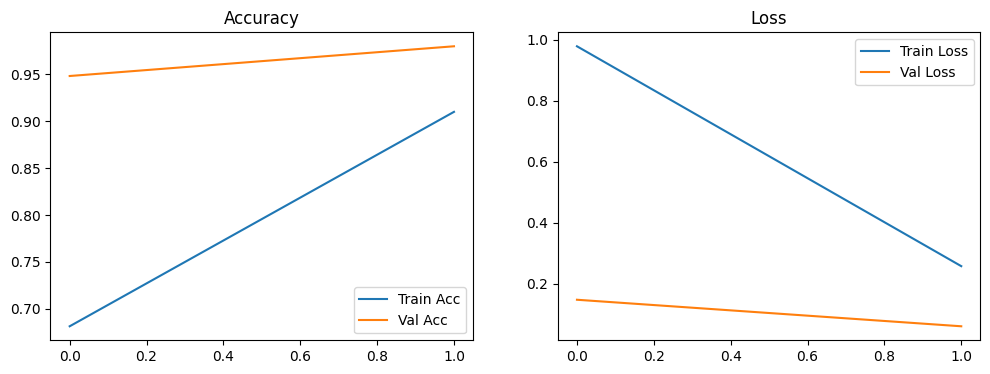

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()

In [12]:
test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [13]:
model.eval()
predicted_labels = []

# 1. UPDATED: Use 'train_data_source' to get class mappings
# (Subsets don't have .class_to_idx, but the source ImageFolder does)
idx_to_class = {v: k for k, v in train_data_source.class_to_idx.items()}

with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        logits = model(x)
        
        # 2. UPDATED: Handle batches correctly
        # argmax returns a list of predictions for the whole batch
        batch_preds = logits.argmax(dim=1)
        
        # Iterate through the batch predictions and map them
        for pred in batch_preds:
            predicted_labels.append(idx_to_class[pred.item()])

# predicted_labels now contains the class names for all test images

In [14]:
for i, label in enumerate(predicted_labels[:32]):
    print(f"Image {i+1}: {label}")

Image 1: Apricot
Image 2: Grape Blue
Image 3: Mango
Image 4: Grape Blue
Image 5: Mango
Image 6: Watermelon
Image 7: Apricot
Image 8: Mango
Image 9: Grape Blue
Image 10: Potato Red
Image 11: Raspberry
Image 12: Papaya
Image 13: Tomato
Image 14: Avocado
Image 15: Lemon
Image 16: Avocado
Image 17: Cherry
Image 18: Papaya
Image 19: Corn
Image 20: Raspberry
Image 21: Corn
Image 22: Tomato
Image 23: Limes
Image 24: Cactus fruit
Image 25: Cherry
Image 26: Cherry
Image 27: Avocado
Image 28: Tomato
Image 29: Limes
Image 30: Avocado
Image 31: Corn
Image 32: Papaya


In [15]:
# Imports hinzufügen
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os

# Klassen-Namen aus dem Trainingsset holen (falls noch nicht definiert)
class_names = full_train_dataset.classes

# wo liegen die bilder?
TEST_DIR = "./downloads" 
IMG_SIZE = 100 

# wir müssen die bilder genau so behandeln wie im training (clean_transforms)
custom_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# alle bilder aus dem ordner laden
# Prüfen, ob der Ordner existiert, sonst erstellen (optional)
if not os.path.exists(TEST_DIR):
    print(f"Ordner {TEST_DIR} nicht gefunden.")
    image_files = []
else:
    image_files = [f for f in os.listdir(TEST_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]

if len(image_files) == 0:
    print(f"❌ Keine Bilder in '{TEST_DIR}' gefunden! Bitte Pfad prüfen.")
else:
    print(f"🔎 Teste {len(image_files)} externe Bilder...")

    plt.figure(figsize=(15, 10))
    model.eval() # prüfungs-modus

    for i, img_name in enumerate(image_files):
        try:
            # 1. bild laden
            img_path = os.path.join(TEST_DIR, img_name)
            image = Image.open(img_path).convert('RGB')
            
            # 2. bild vorbereiten
            # WICHTIG: 'device' statt 'DEVICE' nutzen (wie in Zelle 4 definiert)
            input_tensor = custom_transform(image).unsqueeze(0).to(device)
            
            # 3. vorhersage
            with torch.no_grad():
                outputs = model(input_tensor)
                probs = F.softmax(outputs, dim=1)
                conf, pred_idx = torch.max(probs, 1)
            
            # 4. ergebnis anzeigen
            predicted_class = class_names[pred_idx.item()]
            confidence = conf.item() * 100
            
            ax = plt.subplot(4, 4, i+1)
            
            # anzeigen
            img_display = input_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()
            img_display = img_display * 0.5 + 0.5
            img_display = np.clip(img_display, 0, 1)
            
            plt.imshow(img_display)
            plt.axis('off')
            
            # Farbe je nach Sicherheit
            title_color = 'green' if confidence > 80 else 'orange'
            if confidence < 40: title_color = 'red'
                
            plt.title(f"{predicted_class}\n({confidence:.1f}%)", 
                      color=title_color, fontsize=12, fontweight='bold')
                      
        except Exception as e:
            print(f"Fehler bei Bild {img_name}: {e}")

    plt.tight_layout()
    plt.show()

NameError: name 'full_train_dataset' is not defined